# Semantic Linker — Fine-tuning complet de XLM-R Base sur Kaggle — V1.1 clean run

Ce notebook entraîne **un seul modèle**, `FacebookAI/xlm-roberta-base`, pour le Semantic Linker quantitatif.

Architecture :

```text
FULL MESSAGE + [Q]target quantity[/Q]
                │
                ▼
           XLM-R Base
       12 layers, hidden=768
                │
       représentation <s>
          /           \
         /             \
 FIELD head           ROLE head
  768 → 12             768 → 10
         \             /
          \           /
     compatibility decoder
                │
   confidence + margin abstention
                │
    SemanticLink / UNRESOLVED
```

Le notebook couvre tout le cycle : environnement, données, tokenizer, `[Q]`/`[/Q]`, modèle à deux heads, fine-tuning end-to-end, validation, sélection du meilleur checkpoint, calibration des seuils, test final, export complet et démo d'inférence.

## Avant d'exécuter

Dans Kaggle :

- active **GPU** ;
- active **Internet** pour télécharger XLM-R la première fois ;
- ajoute comme Input les trois fichiers :
  - `semantic_linker_train_v1_1.jsonl`
  - `semantic_linker_val_v1_1.jsonl`
  - `semantic_linker_test_v1_1.jsonl`

Le notebook ne modifie jamais les splits.

## Cellule 1 — Environnement et hyperparamètres

Cette version V1.1 prépare le **run final propre** après le premier run pilote.

Le pilote a encore amélioré `VAL pair_macro_f1` à l'epoch 5, donc 5 epochs étaient une limite trop courte pour laisser l'early stopping décider. On utilise maintenant :

- batch physique 8 ;
- gradient accumulation 2 → batch effectif 16 ;
- AdamW, learning rate `2e-5` ;
- warmup 10 % ;
- **maximum 10 epochs** ;
- early stopping après 2 epochs consécutifs sans amélioration ;
- AMP + gradient checkpointing.

Le notebook fixe aussi explicitement `use_cache=False` pendant le gradient checkpointing et ne fait avancer le learning-rate scheduler que lorsqu'AMP a réellement exécuté `optimizer.step()`.


In [2]:
import os, sys, math, json, random, shutil, subprocess, importlib.util
from pathlib import Path
from collections import Counter

required_packages = {
    'transformers': 'transformers',
    'sklearn': 'scikit-learn',
    'sentencepiece': 'sentencepiece',
    'safetensors': 'safetensors',
}
missing = [pip_name for module_name, pip_name in required_packages.items() if importlib.util.find_spec(module_name) is None]
if missing:
    print('Installing missing packages:', missing)
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *missing])

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
import transformers
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print('Python:', sys.version.split()[0])
print('PyTorch:', torch.__version__)
print('Transformers:', transformers.__version__)
print('CUDA available:', torch.cuda.is_available())

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if DEVICE.type != 'cuda':
    raise RuntimeError('GPU non détecté. Active un accélérateur GPU dans Kaggle.')
print('GPU:', torch.cuda.get_device_name(0))
props = torch.cuda.get_device_properties(0)
print('GPU memory:', round(props.total_memory / 1024**3, 2), 'GB')
print('CUDA runtime:', torch.version.cuda)

SEED = 42

def reset_all_seeds(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

reset_all_seeds(SEED)

MODEL_NAME = 'FacebookAI/xlm-roberta-base'
TRAIN_FILENAME = 'semantic_linker_train_v1_1.jsonl'
VAL_FILENAME = 'semantic_linker_val_v1_1.jsonl'
TEST_FILENAME = 'semantic_linker_test_v1_1.jsonl'

BATCH_SIZE = 8
GRAD_ACCUM_STEPS = 2
EFFECTIVE_BATCH_SIZE = BATCH_SIZE * GRAD_ACCUM_STEPS
MAX_EPOCHS = 10
EARLY_STOPPING_PATIENCE = 2
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.10
MAX_GRAD_NORM = 1.0
DROPOUT = 0.10
FIELD_LOSS_WEIGHT = 1.0
ROLE_LOSS_WEIGHT = 1.0
USE_AMP = True
USE_GRADIENT_CHECKPOINTING = True
TARGET_ACCEPTED_PRECISION = 0.98

WORK_DIR = Path('/kaggle/working/semantic_linker_xlmr_base')
BEST_DIR = WORK_DIR / 'best_checkpoint'
EXPORT_DIR = WORK_DIR / 'final_export'
BEST_DIR.mkdir(parents=True, exist_ok=True)
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

print('Device:', DEVICE)
print('Model:', MODEL_NAME)
print('Effective batch size:', EFFECTIVE_BATCH_SIZE)

Python: 3.12.13
PyTorch: 2.10.0+cu128
Transformers: 5.0.0
CUDA available: True
GPU: Tesla T4
GPU memory: 14.56 GB
CUDA runtime: 12.8
Device: cuda
Model: FacebookAI/xlm-roberta-base
Effective batch size: 16


## Cellule 2 — Charger TRAIN / VAL / TEST et revérifier l'absence de leakage

Kaggle choisit librement le nom du dossier Input. On recherche donc les trois fichiers récursivement puis on confirme : 2100 / 450 / 450, aucun `sample_id` commun et aucun `group_id` commun.

In [3]:
def find_input_file(filename):
    matches = list(Path('/kaggle/input').rglob(filename))
    if not matches:
        raise FileNotFoundError(f'{filename} introuvable sous /kaggle/input')
    if len(matches) > 1:
        print('WARNING: plusieurs copies trouvées pour', filename)
        for p in matches: print(' -', p)
    return matches[0]

def load_jsonl(path):
    records=[]
    with path.open('r', encoding='utf-8') as f:
        for line_no, line in enumerate(f, 1):
            line=line.strip()
            if not line: continue
            records.append(json.loads(line))
    return records

TRAIN_PATH=find_input_file(TRAIN_FILENAME)
VAL_PATH=find_input_file(VAL_FILENAME)
TEST_PATH=find_input_file(TEST_FILENAME)
print('TRAIN:', TRAIN_PATH)
print('VAL  :', VAL_PATH)
print('TEST :', TEST_PATH)

train_records=load_jsonl(TRAIN_PATH)
val_records=load_jsonl(VAL_PATH)
test_records=load_jsonl(TEST_PATH)
assert len(train_records)==2100
assert len(val_records)==450
assert len(test_records)==450

datasets={'train':train_records,'val':val_records,'test':test_records}
sample_sets={k:{r['sample_id'] for r in v} for k,v in datasets.items()}
group_sets={k:{r['group_id'] for r in v} for k,v in datasets.items()}
for a,b in [('train','val'),('train','test'),('val','test')]:
    assert not (sample_sets[a] & sample_sets[b]), f'sample leakage {a}/{b}'
    assert not (group_sets[a] & group_sets[b]), f'group leakage {a}/{b}'
all_records=train_records+val_records+test_records
assert len(all_records)==3000
assert len({r['sample_id'] for r in all_records})==3000
print('✅ Aucun sample_id leakage')
print('✅ Aucun group_id leakage')
for name,recs in datasets.items():
    print(name.upper(), len(recs), dict(Counter(r['language'] for r in recs)), 'groups=', len({r['group_id'] for r in recs}))

TRAIN: /kaggle/input/datasets/ahmedabdelhedii/semantic-linker-data/semantic_linker_train_v1_1.jsonl
VAL  : /kaggle/input/datasets/ahmedabdelhedii/semantic-linker-data/semantic_linker_val_v1_1.jsonl
TEST : /kaggle/input/datasets/ahmedabdelhedii/semantic-linker-data/semantic_linker_test_v1_1.jsonl
✅ Aucun sample_id leakage
✅ Aucun group_id leakage
TRAIN 2100 {'en': 840, 'fr': 840, 'mixed': 420} groups= 309
VAL 450 {'en': 180, 'mixed': 90, 'fr': 180} groups= 66
TEST 450 {'fr': 180, 'en': 180, 'mixed': 90} groups= 69


## Cellule 3 — Taxonomie et compatibility rules

On reproduit exactement les sorties figées du projet : 12 FIELD, 10 ROLE, puis `QuantityDimension → FIELD` et `FIELD → ROLE`. Ces règles seront utilisées au décodage, pas pour remplacer l'apprentissage du Transformer.

In [4]:
FIELD_LABELS=[
 'requested_usable_capacity_tib','client_count','average_file_size_gb','max_file_size_gb',
 'total_file_count','read_write_ratio','target_read_gbps','target_write_gbps','max_budget_usd',
 'max_power_w','annual_growth_percent','__UNRESOLVED__']
ROLE_LABELS=['maximum_limit','minimum_limit','target','current_value','expected_value','average_value','total_count','ratio_component','growth_rate','unspecified']
FIELD_TO_ID={x:i for i,x in enumerate(FIELD_LABELS)}
ID_TO_FIELD={i:x for x,i in FIELD_TO_ID.items()}
ROLE_TO_ID={x:i for i,x in enumerate(ROLE_LABELS)}
ID_TO_ROLE={i:x for x,i in ROLE_TO_ID.items()}
NUM_FIELDS=len(FIELD_LABELS); NUM_ROLES=len(ROLE_LABELS)
UNRESOLVED_FIELD_ID=FIELD_TO_ID['__UNRESOLVED__']
UNSPECIFIED_ROLE_ID=ROLE_TO_ID['unspecified']

ALLOWED_FIELDS_BY_DIMENSION={
 'capacity':{'requested_usable_capacity_tib','__UNRESOLVED__'},
 'file_size':{'average_file_size_gb','max_file_size_gb','__UNRESOLVED__'},
 'throughput':{'target_read_gbps','target_write_gbps','__UNRESOLVED__'},
 'power':{'max_power_w','__UNRESOLVED__'},
 'money':{'max_budget_usd','__UNRESOLVED__'},
 'percent':{'read_write_ratio','annual_growth_percent','__UNRESOLVED__'},
 'count':{'client_count','total_file_count','__UNRESOLVED__'},
 'unknown':set(FIELD_LABELS),
}
ALLOWED_ROLES_BY_FIELD={
 'requested_usable_capacity_tib':{'target','current_value','unspecified'},
 'client_count':{'total_count','unspecified'},
 'average_file_size_gb':{'average_value','unspecified'},
 'max_file_size_gb':{'maximum_limit','unspecified'},
 'total_file_count':{'total_count','unspecified'},
 'read_write_ratio':{'ratio_component','unspecified'},
 'target_read_gbps':{'target','current_value','minimum_limit','unspecified'},
 'target_write_gbps':{'target','current_value','minimum_limit','unspecified'},
 'max_budget_usd':{'maximum_limit','current_value','unspecified'},
 'max_power_w':{'maximum_limit','current_value','expected_value','unspecified'},
 'annual_growth_percent':{'growth_rate','unspecified'},
 '__UNRESOLVED__':{'unspecified'},
}
assert NUM_FIELDS==12 and NUM_ROLES==10
for r in all_records:
    assert r['field'] in ALLOWED_FIELDS_BY_DIMENSION[r['dimension']]
    assert r['role'] in ALLOWED_ROLES_BY_FIELD[r['field']]
print('✅ Taxonomie et compatibility rules validées')

✅ Taxonomie et compatibility rules validées


## Cellule 4 — Tokenizer XLM-R + `[Q]` et `[/Q]`

On ajoute les deux marqueurs comme **special tokens** pour qu'ils restent atomiques. Le modèle sera ensuite redimensionné avec `resize_token_embeddings(len(tokenizer))`.

In [5]:
SPECIAL_TOKENS={'additional_special_tokens':['[Q]','[/Q]']}
tokenizer=AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
vocab_before=len(tokenizer)
num_added=tokenizer.add_special_tokens(SPECIAL_TOKENS)
print('Vocabulary before:', vocab_before)
print('Added:', num_added)
print('Vocabulary after:', len(tokenizer))

sample='Around [Q]200[/Q] hosts will mount the shared filesystem.'
toks=tokenizer.tokenize(sample)
print(toks)
assert '[Q]' in toks and '[/Q]' in toks
Q_ID=tokenizer.convert_tokens_to_ids('[Q]')
Q_CLOSE_ID=tokenizer.convert_tokens_to_ids('[/Q]')
print('[Q] id=',Q_ID,'[/Q] id=',Q_CLOSE_ID)

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Vocabulary before: 250002
Added: 2
Vocabulary after: 250004
['▁A', 'round', '[Q]', '▁200', '[/Q]', '▁host', 's', '▁will', '▁', 'mount', '▁the', '▁shared', '▁file', 'system', '.']
[Q] id= 250002 [/Q] id= 250003


## Cellule 5 — Choisir `MAX_LENGTH` à partir du corpus réel

On mesure toutes les longueurs tokenisées. Si le maximum est ≤256, on choisit le multiple de 16 juste au-dessus. Sinon on monte jusqu'à 512. Puis on vérifie que chaque `[Q]...[/Q]` survit à la tokenisation.

In [6]:
def token_length(text):
    return len(tokenizer(text, add_special_tokens=True, truncation=False)['input_ids'])
lengths=np.array([token_length(r['marked_text']) for r in all_records])
for p in [0,50,90,95,99,100]:
    val=int(lengths.min()) if p==0 else int(lengths.max()) if p==100 else int(np.percentile(lengths,p))
    print(f'p{p:02d}:', val)
raw_max=int(lengths.max())
if raw_max>512:
    raise RuntimeError('Un exemple dépasse 512 tokens.')
MAX_LENGTH=max(64, int(math.ceil(raw_max/16)*16))
MAX_LENGTH=min(MAX_LENGTH,512)
print('MAX_LENGTH=',MAX_LENGTH)
for r in all_records:
    ids=tokenizer(r['marked_text'], truncation=True, max_length=MAX_LENGTH)['input_ids']
    assert Q_ID in ids and Q_CLOSE_ID in ids, r['sample_id']
print('✅ Tous les marqueurs [Q] survivent')

p00: 15
p50: 47
p90: 60
p95: 64
p99: 71
p100: 81
MAX_LENGTH= 96
✅ Tous les marqueurs [Q] survivent


## Cellule 6 — Dataset PyTorch et DataLoaders

Le padding est dynamique par batch. Chaque exemple transporte le texte, les deux labels, la dimension et le `sample_id`.

In [7]:
class SemanticDataset(Dataset):
    def __init__(self, records): self.records=records
    def __len__(self): return len(self.records)
    def __getitem__(self, idx):
        r=self.records[idx]
        return {'text':r['marked_text'],'field_id':FIELD_TO_ID[r['field']], 'role_id':ROLE_TO_ID[r['role']], 'dimension':r['dimension'], 'sample_id':r['sample_id']}

def collate_batch(batch):
    enc=tokenizer([x['text'] for x in batch], padding=True, truncation=True, max_length=MAX_LENGTH, return_tensors='pt')
    enc['field_labels']=torch.tensor([x['field_id'] for x in batch],dtype=torch.long)
    enc['role_labels']=torch.tensor([x['role_id'] for x in batch],dtype=torch.long)
    enc['dimensions']=[x['dimension'] for x in batch]
    enc['sample_ids']=[x['sample_id'] for x in batch]
    return enc

train_loader=DataLoader(SemanticDataset(train_records),batch_size=BATCH_SIZE,shuffle=True,collate_fn=collate_batch,num_workers=2,pin_memory=True)
val_loader=DataLoader(SemanticDataset(val_records),batch_size=BATCH_SIZE,shuffle=False,collate_fn=collate_batch,num_workers=2,pin_memory=True)
test_loader=DataLoader(SemanticDataset(test_records),batch_size=BATCH_SIZE,shuffle=False,collate_fn=collate_batch,num_workers=2,pin_memory=True)
batch=next(iter(train_loader))
print('input_ids',batch['input_ids'].shape)
print('FIELD labels',batch['field_labels'].shape,'ROLE labels',batch['role_labels'].shape)
print(tokenizer.decode(batch['input_ids'][0],skip_special_tokens=False))

input_ids torch.Size([8, 66])
FIELD labels torch.Size([8]) ROLE labels torch.Size([8])
<s> Sur la present platform, les data leaving storage vers les compute nodes tournent autour de[Q] 70 GB/s[/Q] .</s><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad>


## Cellule 7 — XLM-R Base + deux heads

`AutoModel` charge l'encoder. Après redimensionnement des embeddings, on utilise la représentation du premier token `<s>` de la dernière couche, puis `Linear(768,12)` et `Linear(768,10)`.

Avant de construire le modèle, on **réinitialise les seeds** pour que les deux nouvelles heads et les nouveaux embeddings soient reproductibles même si la cellule est relancée.

Avec le gradient checkpointing, `use_cache=False` est fixé explicitement : le cache n'est pas utile pour notre entraînement de classification et cela évite le warning d'incompatibilité.


In [8]:
class XLMRSemanticLinker(nn.Module):
    def __init__(
        self,
        model_name,
        tokenizer_size,
        num_fields,
        num_roles,
        dropout=0.1,
        gradient_checkpointing=True,
    ):
        super().__init__()

        self.encoder = AutoModel.from_pretrained(model_name)
        self.encoder.resize_token_embeddings(tokenizer_size)

        if gradient_checkpointing:
            # Gradient checkpointing trades compute for memory.
            # The forward cache is not needed for this classification task.
            if hasattr(self.encoder.config, "use_cache"):
                self.encoder.config.use_cache = False
            self.encoder.gradient_checkpointing_enable()

        hidden = self.encoder.config.hidden_size

        self.dropout = nn.Dropout(dropout)
        self.field_head = nn.Linear(hidden, num_fields)
        self.role_head = nn.Linear(hidden, num_roles)

    def forward(self, input_ids, attention_mask):
        out = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
            return_dict=True,
        )

        h = self.dropout(
            out.last_hidden_state[:, 0, :]
        )

        return (
            self.field_head(h),
            self.role_head(h),
        )


# Important for a reproducible clean rerun.
reset_all_seeds(SEED)

model = XLMRSemanticLinker(
    MODEL_NAME,
    len(tokenizer),
    NUM_FIELDS,
    NUM_ROLES,
    DROPOUT,
    USE_GRADIENT_CHECKPOINTING,
).to(DEVICE)

print("Hidden=", model.encoder.config.hidden_size)
print("Layers=", model.encoder.config.num_hidden_layers)
print("Heads=", model.encoder.config.num_attention_heads)
print(
    "Total params=",
    f"{sum(p.numel() for p in model.parameters()):,}",
)
print(
    "Trainable=",
    f"{sum(p.numel() for p in model.parameters() if p.requires_grad):,}",
)

if hasattr(model.encoder.config, "use_cache"):
    print(
        "use_cache=",
        model.encoder.config.use_cache,
    )

model.eval()

with torch.no_grad():
    fl, rl = model(
        batch["input_ids"][:2].to(DEVICE),
        batch["attention_mask"][:2].to(DEVICE),
    )

print(
    "FIELD logits",
    fl.shape,
    "ROLE logits",
    rl.shape,
)

assert fl.shape == (2, 12)
assert rl.shape == (2, 10)

print("✅ Forward pass réussi")


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: FacebookAI/xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


Hidden= 768
Layers= 12
Heads= 12
Total params= 278,062,102
Trainable= 278,062,102
use_cache= False
FIELD logits torch.Size([2, 12]) ROLE logits torch.Size([2, 10])
✅ Forward pass réussi


## Cellule 8 — Décodage contraint FIELD + ROLE

On combine `log P(field) + log P(role)` uniquement sur les couples valides selon la dimension et la matrice FIELD→ROLE. On obtient le meilleur couple, sa confiance et la marge top1-top2.

In [9]:
def valid_pair_ids_for_dimension(dimension):
    pairs=[]
    for field in FIELD_LABELS:
        if field not in ALLOWED_FIELDS_BY_DIMENSION[dimension]: continue
        fi=FIELD_TO_ID[field]
        for role in ROLE_LABELS:
            if role in ALLOWED_ROLES_BY_FIELD[field]: pairs.append((fi,ROLE_TO_ID[role]))
    return pairs
VALID_PAIR_CACHE={d:valid_pair_ids_for_dimension(d) for d in ALLOWED_FIELDS_BY_DIMENSION}

def decode_valid_pairs(field_logits, role_logits, dimensions):
    flp=torch.log_softmax(field_logits,dim=-1)
    rlp=torch.log_softmax(role_logits,dim=-1)
    pf=[]; pr=[]; conf=[]; margin=[]
    for i,dim in enumerate(dimensions):
        pairs=VALID_PAIR_CACHE[dim]
        scores=torch.stack([flp[i,fi]+rlp[i,ri] for fi,ri in pairs])
        probs=torch.softmax(scores,dim=0)
        order=torch.argsort(probs,descending=True)
        best=int(order[0]); fi,ri=pairs[best]
        p1=float(probs[best].detach().cpu())
        p2=float(probs[int(order[1])].detach().cpu()) if len(order)>1 else 0.0
        pf.append(fi); pr.append(ri); conf.append(p1); margin.append(p1-p2)
    return {'field_ids':np.array(pf),'role_ids':np.array(pr),'confidence':np.array(conf),'margin':np.array(margin)}

for dim in ['power','throughput','unknown']:
    print()
    print(dim, [(ID_TO_FIELD[f], ID_TO_ROLE[r]) for f, r in VALID_PAIR_CACHE[dim]])


power [('max_power_w', 'maximum_limit'), ('max_power_w', 'current_value'), ('max_power_w', 'expected_value'), ('max_power_w', 'unspecified'), ('__UNRESOLVED__', 'unspecified')]

throughput [('target_read_gbps', 'minimum_limit'), ('target_read_gbps', 'target'), ('target_read_gbps', 'current_value'), ('target_read_gbps', 'unspecified'), ('target_write_gbps', 'minimum_limit'), ('target_write_gbps', 'target'), ('target_write_gbps', 'current_value'), ('target_write_gbps', 'unspecified'), ('__UNRESOLVED__', 'unspecified')]

unknown [('requested_usable_capacity_tib', 'target'), ('requested_usable_capacity_tib', 'current_value'), ('requested_usable_capacity_tib', 'unspecified'), ('client_count', 'total_count'), ('client_count', 'unspecified'), ('average_file_size_gb', 'average_value'), ('average_file_size_gb', 'unspecified'), ('max_file_size_gb', 'maximum_limit'), ('max_file_size_gb', 'unspecified'), ('total_file_count', 'total_count'), ('total_file_count', 'unspecified'), ('read_write_ratio'

## Cellule 9 — Loss, AdamW, scheduler, AMP et fonctions d'entraînement

`L_total = L_field + L_role`. Les masks restent au décodage, pas dans la loss.

### Correction V1.1 importante

Avec AMP, `GradScaler.step(optimizer)` peut exceptionnellement **sauter** un update si des gradients `inf/NaN` sont détectés. Le scheduler ne doit alors pas avancer comme si `optimizer.step()` avait eu lieu.

La V1.1 compare le `GradScaler` avant/après l'update :

- scale identique ou plus grande → optimizer update exécuté → `scheduler.step()` ;
- scale diminuée → AMP a sauté l'optimizer update → scheduler inchangé.

Le nombre de steps AMP sautés est aussi affiché pour audit.


In [10]:
field_loss_fn = nn.CrossEntropyLoss()
role_loss_fn = nn.CrossEntropyLoss()

optimizer = AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

steps_per_epoch = math.ceil(
    len(train_loader) / GRAD_ACCUM_STEPS
)

total_steps = (
    steps_per_epoch * MAX_EPOCHS
)

warmup_steps = int(
    total_steps * WARMUP_RATIO
)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

try:
    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=USE_AMP,
    )
except TypeError:
    scaler = torch.cuda.amp.GradScaler(
        enabled=USE_AMP,
    )


def autocast_context():
    return torch.autocast(
        device_type="cuda",
        dtype=torch.float16,
        enabled=USE_AMP,
    )


def train_one_epoch(model, loader):
    model.train()
    optimizer.zero_grad(set_to_none=True)

    total = 0.0
    field_total = 0.0
    role_total = 0.0

    optimizer_updates = 0
    amp_skipped_updates = 0

    for bi, b in enumerate(loader):
        ids = b["input_ids"].to(
            DEVICE,
            non_blocking=True,
        )
        mask = b["attention_mask"].to(
            DEVICE,
            non_blocking=True,
        )
        fy = b["field_labels"].to(
            DEVICE,
            non_blocking=True,
        )
        ry = b["role_labels"].to(
            DEVICE,
            non_blocking=True,
        )

        with autocast_context():
            fl, rl = model(ids, mask)

            lf = field_loss_fn(fl, fy)
            lr = role_loss_fn(rl, ry)

            loss = (
                FIELD_LOSS_WEIGHT * lf
                + ROLE_LOSS_WEIGHT * lr
            )

            scaled = loss / GRAD_ACCUM_STEPS

        scaler.scale(scaled).backward()

        do_step = (
            (bi + 1) % GRAD_ACCUM_STEPS == 0
            or (bi + 1) == len(loader)
        )

        if do_step:
            scaler.unscale_(optimizer)

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                MAX_GRAD_NORM,
            )

            scale_before = scaler.get_scale()

            scaler.step(optimizer)
            scaler.update()

            scale_after = scaler.get_scale()

            # If scale decreases, GradScaler detected inf/NaN and skipped
            # optimizer.step(). In that case the LR scheduler must NOT move.
            optimizer_step_executed = (
                scale_after >= scale_before
            )

            if optimizer_step_executed:
                scheduler.step()
                optimizer_updates += 1
            else:
                amp_skipped_updates += 1

            optimizer.zero_grad(
                set_to_none=True,
            )

        total += float(loss.detach().cpu())
        field_total += float(lf.detach().cpu())
        role_total += float(lr.detach().cpu())

    n = len(loader)

    return {
        "loss": total / n,
        "field_loss": field_total / n,
        "role_loss": role_total / n,
        "optimizer_updates": optimizer_updates,
        "amp_skipped_updates": amp_skipped_updates,
        "last_lr": float(
            scheduler.get_last_lr()[0]
        ),
    }


@torch.no_grad()
def collect_predictions(model, loader):
    model.eval()

    FL = []
    RL = []
    TF = []
    TR = []
    dims = []
    sids = []

    loss_total = 0.0

    for b in loader:
        ids = b["input_ids"].to(
            DEVICE,
            non_blocking=True,
        )
        mask = b["attention_mask"].to(
            DEVICE,
            non_blocking=True,
        )
        fy = b["field_labels"].to(
            DEVICE,
            non_blocking=True,
        )
        ry = b["role_labels"].to(
            DEVICE,
            non_blocking=True,
        )

        with autocast_context():
            fl, rl = model(ids, mask)

            lf = field_loss_fn(fl, fy)
            lr = role_loss_fn(rl, ry)
            loss = lf + lr

        loss_total += float(
            loss.detach().cpu()
        )

        FL.append(
            fl.float().cpu()
        )
        RL.append(
            rl.float().cpu()
        )

        TF.extend(
            fy.cpu().numpy().tolist()
        )
        TR.extend(
            ry.cpu().numpy().tolist()
        )

        dims.extend(
            b["dimensions"]
        )
        sids.extend(
            b["sample_ids"]
        )

    FL = torch.cat(FL)
    RL = torch.cat(RL)

    TF = np.array(TF)
    TR = np.array(TR)

    dec = decode_valid_pairs(
        FL,
        RL,
        dims,
    )

    PF = dec["field_ids"]
    PR = dec["role_ids"]

    true_pairs = [
        f"{f}::{r}"
        for f, r in zip(TF, TR)
    ]

    pred_pairs = [
        f"{f}::{r}"
        for f, r in zip(PF, PR)
    ]

    umask = (
        TF == UNRESOLVED_FIELD_ID
    )

    urec = (
        float(
            np.mean(
                PF[umask]
                == UNRESOLVED_FIELD_ID
            )
        )
        if umask.any()
        else float("nan")
    )

    metrics = {
        "loss": (
            loss_total / len(loader)
        ),
        "field_accuracy": accuracy_score(
            TF,
            PF,
        ),
        "field_macro_f1": f1_score(
            TF,
            PF,
            average="macro",
            zero_division=0,
        ),
        "role_accuracy": accuracy_score(
            TR,
            PR,
        ),
        "role_macro_f1": f1_score(
            TR,
            PR,
            average="macro",
            zero_division=0,
        ),
        "pair_accuracy": accuracy_score(
            true_pairs,
            pred_pairs,
        ),
        "pair_macro_f1": f1_score(
            true_pairs,
            pred_pairs,
            average="macro",
            zero_division=0,
        ),
        "unresolved_recall": urec,
    }

    return {
        "metrics": metrics,
        "field_logits": FL,
        "role_logits": RL,
        "true_fields": TF,
        "true_roles": TR,
        "pred_fields": PF,
        "pred_roles": PR,
        "confidence": dec["confidence"],
        "margin": dec["margin"],
        "dimensions": dims,
        "sample_ids": sids,
    }


print(
    "Batches/epoch=",
    len(train_loader),
    "optimizer steps/epoch=",
    steps_per_epoch,
    "total scheduled steps=",
    total_steps,
    "warmup=",
    warmup_steps,
)


Batches/epoch= 263 optimizer steps/epoch= 132 total scheduled steps= 1320 warmup= 132


## Cellule 10 — Fine-tuning end-to-end — run final propre

TRAIN modifie les poids ; VAL ne fait aucun gradient ; TEST reste fermé.

Le maximum est maintenant 10 epochs uniquement pour laisser l'**early stopping** décider du point d'arrêt. On ne force pas 10 epochs : deux epochs consécutifs sans amélioration de `VAL pair_macro_f1` arrêtent l'entraînement.

Chaque epoch affiche aussi :

- le nombre d'updates optimizer réellement exécutés ;
- le nombre d'updates AMP sautés ;
- le learning rate final de l'epoch.


In [11]:
history = []
best_val_score = -1.0
best_epoch = None
no_improve = 0

BEST_STATE_PATH = (
    BEST_DIR
    / "semantic_linker_best_state.pt"
)

for epoch in range(
    1,
    MAX_EPOCHS + 1,
):
    print()
    print("=" * 70)
    print(
        f"EPOCH {epoch}/{MAX_EPOCHS}"
    )
    print("=" * 70)

    tm = train_one_epoch(
        model,
        train_loader,
    )

    vo = collect_predictions(
        model,
        val_loader,
    )
    vm = vo["metrics"]

    row = {
        "epoch": epoch,
        "train_loss": tm["loss"],
        "train_field_loss": tm["field_loss"],
        "train_role_loss": tm["role_loss"],
        "optimizer_updates": tm["optimizer_updates"],
        "amp_skipped_updates": tm["amp_skipped_updates"],
        "last_lr": tm["last_lr"],
        "val_loss": vm["loss"],
        "val_field_accuracy": vm["field_accuracy"],
        "val_field_macro_f1": vm["field_macro_f1"],
        "val_role_accuracy": vm["role_accuracy"],
        "val_role_macro_f1": vm["role_macro_f1"],
        "val_pair_accuracy": vm["pair_accuracy"],
        "val_pair_macro_f1": vm["pair_macro_f1"],
        "val_unresolved_recall": vm["unresolved_recall"],
    }

    history.append(row)

    print(
        f"train_loss={row['train_loss']:.4f} "
        f"val_loss={row['val_loss']:.4f}"
    )

    print(
        f"FIELD F1={row['val_field_macro_f1']:.4f} "
        f"ROLE F1={row['val_role_macro_f1']:.4f} "
        f"PAIR F1={row['val_pair_macro_f1']:.4f} "
        f"UNRES recall={row['val_unresolved_recall']:.4f}"
    )

    print(
        f"optimizer_updates={row['optimizer_updates']} "
        f"amp_skipped={row['amp_skipped_updates']} "
        f"last_lr={row['last_lr']:.8f}"
    )

    score = row[
        "val_pair_macro_f1"
    ]

    if score > best_val_score + 1e-6:
        best_val_score = score
        best_epoch = epoch
        no_improve = 0

        torch.save(
            model.state_dict(),
            BEST_STATE_PATH,
        )

        print(
            "✅ New best checkpoint"
        )
    else:
        no_improve += 1

        print(
            "No improvement:",
            no_improve,
            "/",
            EARLY_STOPPING_PATIENCE,
        )

        if (
            no_improve
            >= EARLY_STOPPING_PATIENCE
        ):
            print(
                "⏹ Early stopping"
            )
            break

history_df = pd.DataFrame(
    history
)

history_df



EPOCH 1/10
train_loss=4.5573 val_loss=2.6266
FIELD F1=0.6207 ROLE F1=0.4542 PAIR F1=0.2482 UNRES recall=0.0541
optimizer_updates=129 amp_skipped=3 last_lr=0.00001955
✅ New best checkpoint

EPOCH 2/10
train_loss=1.5263 val_loss=0.6331
FIELD F1=0.8633 ROLE F1=0.9233 PAIR F1=0.6726 UNRES recall=1.0000
optimizer_updates=131 amp_skipped=1 last_lr=0.00001785
✅ New best checkpoint

EPOCH 3/10
train_loss=0.4553 val_loss=0.3247
FIELD F1=0.8489 ROLE F1=0.9780 PAIR F1=0.7134 UNRES recall=1.0000
optimizer_updates=132 amp_skipped=0 last_lr=0.00001562
✅ New best checkpoint

EPOCH 4/10
train_loss=0.1974 val_loss=0.2512
FIELD F1=0.9253 ROLE F1=0.9825 PAIR F1=0.7959 UNRES recall=1.0000
optimizer_updates=132 amp_skipped=0 last_lr=0.00001340
✅ New best checkpoint

EPOCH 5/10
train_loss=0.0817 val_loss=0.1494
FIELD F1=0.9570 ROLE F1=0.9891 PAIR F1=0.8691 UNRES recall=1.0000
optimizer_updates=132 amp_skipped=0 last_lr=0.00001118
✅ New best checkpoint

EPOCH 6/10
train_loss=0.0321 val_loss=0.1194
FIELD F1=

,epoch,train_loss,train_field_loss,train_role_loss,optimizer_updates,amp_skipped_updates,last_lr,val_loss,val_field_accuracy,val_field_macro_f1,val_role_accuracy,val_role_macro_f1,val_pair_accuracy,val_pair_macro_f1,val_unresolved_recall
0,1,4.557265,2.395679,2.161587,129,3,0.000020,2.626648,0.702222,0.620734,0.646667,0.454230,0.500000,0.248230,0.054054
1,2,1.526325,0.736818,0.789507,131,1,0.000018,0.633147,0.888889,0.863266,0.937778,0.923310,0.826667,0.672646,1.000000
2,3,0.455348,0.262105,0.193243,132,0,0.000016,0.324678,0.851111,0.848854,0.977778,0.977961,0.828889,0.713441,1.000000
3,4,0.197430,0.143465,0.053965,132,0,0.000013,0.251225,0.928889,0.925265,0.982222,0.982520,0.911111,0.795886,1.000000
4,5,0.081687,0.053671,0.028016,132,0,0.000011,0.149416,0.957778,0.956970,0.988889,0.989086,0.946667,0.869085,1.000000
5,6,0.032062,0.019250,0.012812,132,0,0.000009,0.119430,0.964444,0.963990,0.988889,0.989086,0.953333,0.883015,1.000000
6,7,0.016207,0.009112,0.007095,132,0,0.000007,0.141442,0.968889,0.968479,0.988889,0.989086,0.957778,0.895191,1.000000
7,8,0.010873,0.005722,0.005151,132,0,0.000005,0.123909,0.966667,0.966205,0.988889,0.989086,0.955556,0.890064,1.000000
8,9,0.009060,0.004699,0.004362,132,0,0.000002,0.127053,0.966667,0.966205,0.988889,0.989086,0.955556,0.890064,1.000000


## Cellule 11 — Courbes d'apprentissage

On visualise loss et macro-F1 pour repérer sous-apprentissage ou sur-apprentissage.

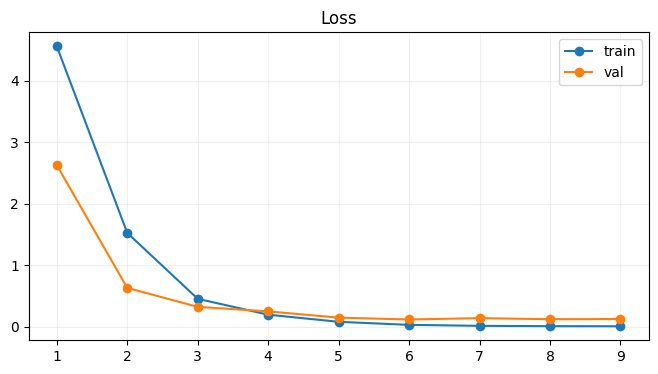

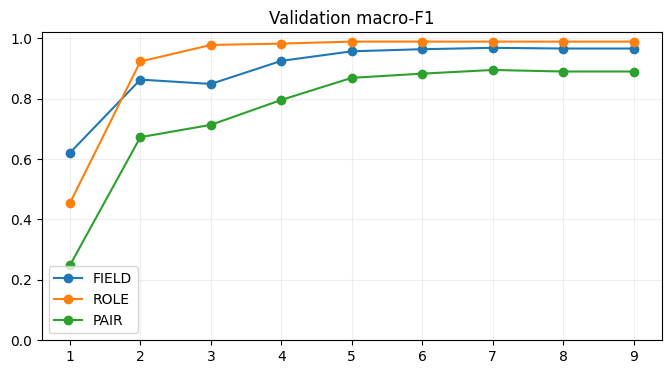

Best epoch= 7 best pair macro-F1= 0.8951905401659096


In [12]:
fig,ax=plt.subplots(figsize=(8,4)); ax.plot(history_df.epoch,history_df.train_loss,marker='o',label='train'); ax.plot(history_df.epoch,history_df.val_loss,marker='o',label='val'); ax.set_title('Loss'); ax.legend(); ax.grid(alpha=.2); plt.show()
fig,ax=plt.subplots(figsize=(8,4)); ax.plot(history_df.epoch,history_df.val_field_macro_f1,marker='o',label='FIELD'); ax.plot(history_df.epoch,history_df.val_role_macro_f1,marker='o',label='ROLE'); ax.plot(history_df.epoch,history_df.val_pair_macro_f1,marker='o',label='PAIR'); ax.set_ylim(0,1.02); ax.set_title('Validation macro-F1'); ax.legend(); ax.grid(alpha=.2); plt.show()
print('Best epoch=',best_epoch,'best pair macro-F1=',best_val_score)

## Cellule 12 — Recharger le meilleur checkpoint et analyser VAL

On recharge le meilleur epoch avant de calibrer les seuils. Le TEST reste encore fermé.

In [13]:
model.load_state_dict(torch.load(BEST_STATE_PATH,map_location=DEVICE)); model.to(DEVICE); model.eval()
val_output=collect_predictions(model,val_loader); val_metrics=val_output['metrics']
print('BEST VALIDATION METRICS')
for k,v in val_metrics.items():
    print(f'{k:22s}: {v:.6f}')
print()
print('FIELD report:')
print(classification_report(
    val_output['true_fields'],
    val_output['pred_fields'],
    labels=list(range(NUM_FIELDS)),
    target_names=FIELD_LABELS,
    zero_division=0,
    digits=4,
))
print()
print('ROLE report:')
print(classification_report(
    val_output['true_roles'],
    val_output['pred_roles'],
    labels=list(range(NUM_ROLES)),
    target_names=ROLE_LABELS,
    zero_division=0,
    digits=4,
))


BEST VALIDATION METRICS
loss                  : 0.141442
field_accuracy        : 0.968889
field_macro_f1        : 0.968479
role_accuracy         : 0.988889
role_macro_f1         : 0.989086
pair_accuracy         : 0.957778
pair_macro_f1         : 0.895191
unresolved_recall     : 1.000000

FIELD report:
                               precision    recall  f1-score   support

requested_usable_capacity_tib     1.0000    1.0000    1.0000        38
                 client_count     1.0000    1.0000    1.0000        38
         average_file_size_gb     0.8261    1.0000    0.9048        38
             max_file_size_gb     1.0000    0.7632    0.8657        38
             total_file_count     1.0000    1.0000    1.0000        38
             read_write_ratio     1.0000    1.0000    1.0000        38
             target_read_gbps     0.9706    0.8919    0.9296        37
            target_write_gbps     0.9000    0.9730    0.9351        37
               max_budget_usd     1.0000    1.0000    1.0

## Cellule 13 — Calibrer confidence + margin sur VAL

Une prédiction résolue n'est acceptée que si le meilleur couple est non-UNRESOLVED, assez confiant et assez séparé du second. On cherche d'abord **accepted precision ≥98 %**, puis la couverture maximale.

In [14]:
import numpy as np
import pandas as pd
def selective_metrics(
    output,
    confidence_threshold,
    margin_threshold
):
    TF = output["true_fields"]
    TR = output["true_roles"]

    PF = output["pred_fields"].copy()
    PR = output["pred_roles"].copy()

    accepted = (
        (PF != UNRESOLVED_FIELD_ID)
        & (output["confidence"] >= confidence_threshold)
        & (output["margin"] >= margin_threshold)
    )

    correct = (PF == TF) & (PR == TR)

    n = int(accepted.sum())

    precision = (
        float(correct[accepted].mean())
        if n > 0
        else np.nan
    )

    coverage = float(accepted.mean())

    FF = PF.copy()
    FR = PR.copy()

    FF[~accepted] = UNRESOLVED_FIELD_ID
    FR[~accepted] = UNSPECIFIED_ROLE_ID

    unresolved_mask = (
        TF == UNRESOLVED_FIELD_ID
    )

    unresolved_recall = (
        float(
            np.mean(
                FF[unresolved_mask]
                == UNRESOLVED_FIELD_ID
            )
        )
        if unresolved_mask.any()
        else np.nan
    )

    final_pair_accuracy = float(
        np.mean(
            (FF == TF) &
            (FR == TR)
        )
    )

    return {
        "confidence_threshold":
            confidence_threshold,

        "margin_threshold":
            margin_threshold,

        "accepted_count":
            n,

        "accepted_precision":
            precision,

        "coverage":
            coverage,

        "unresolved_recall":
            unresolved_recall,

        "final_pair_accuracy":
            final_pair_accuracy,
    }


# --------------------------------------------------
# Fine-grained threshold search
# --------------------------------------------------

rows = []

confidence_values = np.concatenate([
    np.arange(0.90, 0.95, 0.01),
    np.arange(0.95, 0.991, 0.002),
    np.arange(0.992, 1.000, 0.001),
])

margin_values = np.arange(
    0.0,
    0.501,
    0.02
)

for c in confidence_values:
    for m in margin_values:

        result = selective_metrics(
            val_output,
            confidence_threshold=float(c),
            margin_threshold=float(m),
        )

        rows.append(result)


threshold_df = pd.DataFrame(rows)

# Remove configurations accepting nothing
valid = threshold_df[
    threshold_df["accepted_count"] > 0
].copy()


# --------------------------------------------------
# Our safety objective
# --------------------------------------------------

eligible = valid[
    (valid["accepted_precision"]
        >= TARGET_ACCEPTED_PRECISION)
    &
    (valid["unresolved_recall"]
        >= 0.999)
]


if len(eligible) > 0:

    # Primary objective:
    # accepted precision >= 98 %
    #
    # Then maximize useful coverage.

    selected = (
        eligible
        .sort_values(
            [
                "coverage",
                "accepted_precision",
                "final_pair_accuracy",
            ],
            ascending=False,
        )
        .iloc[0]
    )

    threshold_validated = True

    selection_reason = (
        f"accepted_precision >= "
        f"{TARGET_ACCEPTED_PRECISION:.2%}, "
        "unresolved_recall ~= 100%, "
        "then maximum coverage"
    )

else:

    threshold_validated = False

    selected = (
        valid
        .sort_values(
            [
                "accepted_precision",
                "coverage",
            ],
            ascending=False,
        )
        .iloc[0]
    )

    selection_reason = (
        "NO threshold reached target "
        "accepted precision"
    )


CONFIDENCE_THRESHOLD = float(
    selected["confidence_threshold"]
)

MARGIN_THRESHOLD = float(
    selected["margin_threshold"]
)


print("=" * 70)

if threshold_validated:
    print("✅ THRESHOLD VALIDATED")
else:
    print("❌ THRESHOLD NOT YET VALIDATED")

print("=" * 70)

print(
    "Target accepted precision:",
    TARGET_ACCEPTED_PRECISION
)

print(
    "Confidence threshold:",
    CONFIDENCE_THRESHOLD
)

print(
    "Margin threshold:",
    MARGIN_THRESHOLD
)

print(
    "Accepted precision:",
    selected["accepted_precision"]
)

print(
    "Coverage:",
    selected["coverage"]
)

print(
    "Accepted count:",
    int(selected["accepted_count"])
)

print(
    "Unresolved recall:",
    selected["unresolved_recall"]
)

print(
    "Final pair accuracy:",
    selected["final_pair_accuracy"]
)

print(
    "Selection reason:",
    selection_reason
)

print("=" * 70)


display(
    valid.sort_values(
        [
            "accepted_precision",
            "coverage",
        ],
        ascending=False,
    ).head(30)
)

✅ THRESHOLD VALIDATED
Target accepted precision: 0.98
Confidence threshold: 0.966
Margin threshold: 0.0
Accepted precision: 0.981675392670157
Coverage: 0.8488888888888889
Accepted count: 382
Unresolved recall: 1.0
Final pair accuracy: 0.9155555555555556
Selection reason: accepted_precision >= 98.00%, unresolved_recall ~= 100%, then maximum coverage


,confidence_threshold,margin_threshold,accepted_count,accepted_precision,coverage,unresolved_recall,final_pair_accuracy
546,0.982,0.00,351,1.0,0.780000,1.0,0.862222
547,0.982,0.02,351,1.0,0.780000,1.0,0.862222
548,0.982,0.04,351,1.0,0.780000,1.0,0.862222
549,0.982,0.06,351,1.0,0.780000,1.0,0.862222
550,0.982,0.08,351,1.0,0.780000,1.0,0.862222
551,0.982,0.10,351,1.0,0.780000,1.0,0.862222
552,0.982,0.12,351,1.0,0.780000,1.0,0.862222
553,0.982,0.14,351,1.0,0.780000,1.0,0.862222
554,0.982,0.16,351,1.0,0.780000,1.0,0.862222
555,0.982,0.18,351,1.0,0.780000,1.0,0.862222


## Cellule 14 — TEST final

Première utilisation de TEST. On ne change plus modèle, hyperparamètres ni seuils. On mesure les performances contraintes et sélectives.

In [15]:
test_output=collect_predictions(model,test_loader)
test_metrics=test_output['metrics']
test_selective=selective_metrics(
    test_output,
    CONFIDENCE_THRESHOLD,
    MARGIN_THRESHOLD,
)

print('TEST — RAW CONSTRAINED')
for k,v in test_metrics.items():
    print(f'{k:22s}: {v:.6f}')

print()
print('TEST — SELECTIVE')
for k,v in test_selective.items():
    print(f'{k:24s}: {v}')

print()
print('FIELD report:')
print(classification_report(
    test_output['true_fields'],
    test_output['pred_fields'],
    labels=list(range(NUM_FIELDS)),
    target_names=FIELD_LABELS,
    zero_division=0,
    digits=4,
))

print()
print('ROLE report:')
print(classification_report(
    test_output['true_roles'],
    test_output['pred_roles'],
    labels=list(range(NUM_ROLES)),
    target_names=ROLE_LABELS,
    zero_division=0,
    digits=4,
))


TEST — RAW CONSTRAINED
loss                  : 0.133573
field_accuracy        : 0.960000
field_macro_f1        : 0.960008
role_accuracy         : 1.000000
role_macro_f1         : 1.000000
pair_accuracy         : 0.960000
pair_macro_f1         : 0.941259
unresolved_recall     : 1.000000

TEST — SELECTIVE
confidence_threshold    : 0.966
margin_threshold        : 0.0
accepted_count          : 381
accepted_precision      : 0.979002624671916
coverage                : 0.8466666666666667
unresolved_recall       : 1.0
final_pair_accuracy     : 0.9133333333333333

FIELD report:
                               precision    recall  f1-score   support

requested_usable_capacity_tib     1.0000    1.0000    1.0000        37
                 client_count     1.0000    1.0000    1.0000        37
         average_file_size_gb     0.8605    1.0000    0.9250        37
             max_file_size_gb     1.0000    0.8378    0.9118        37
             total_file_count     1.0000    1.0000    1.0000        

## Cellule 15 — Confusion matrices TEST

Elles permettent d'identifier visuellement les confusions `client/file_count`, `avg/max file size`, `read/write throughput`, etc.

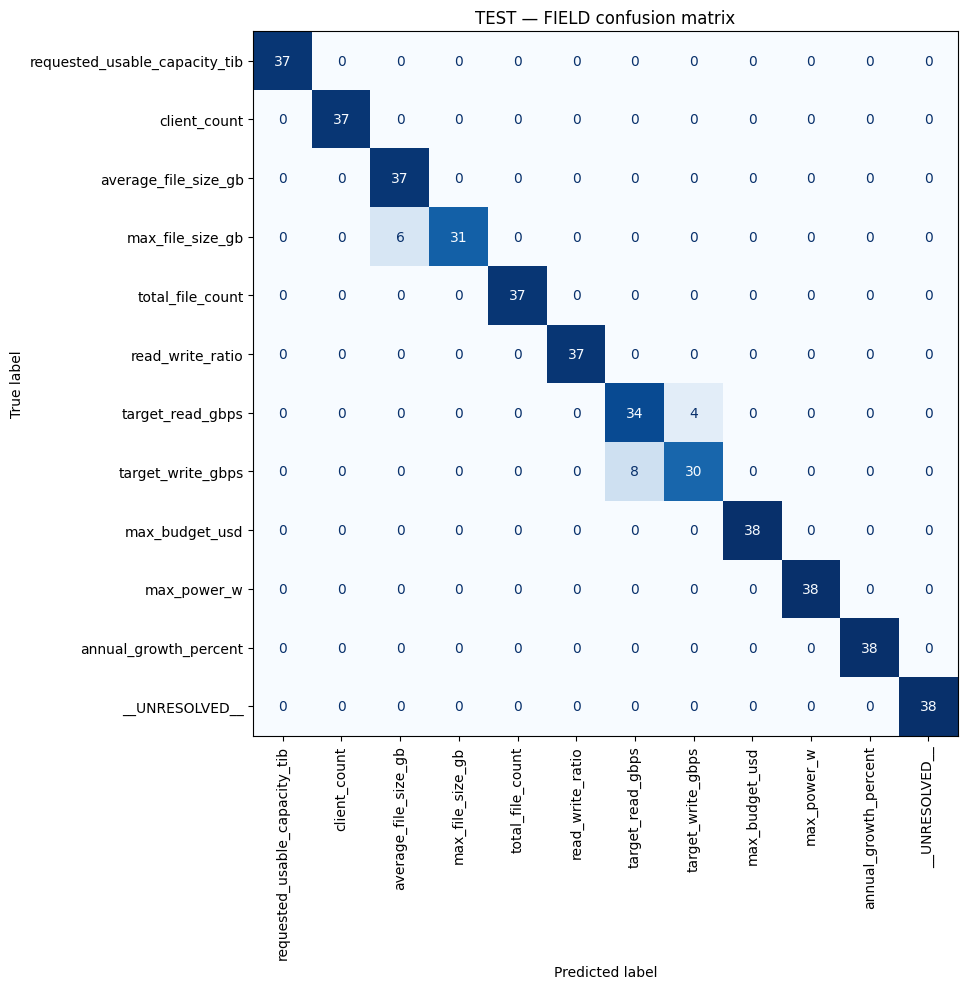

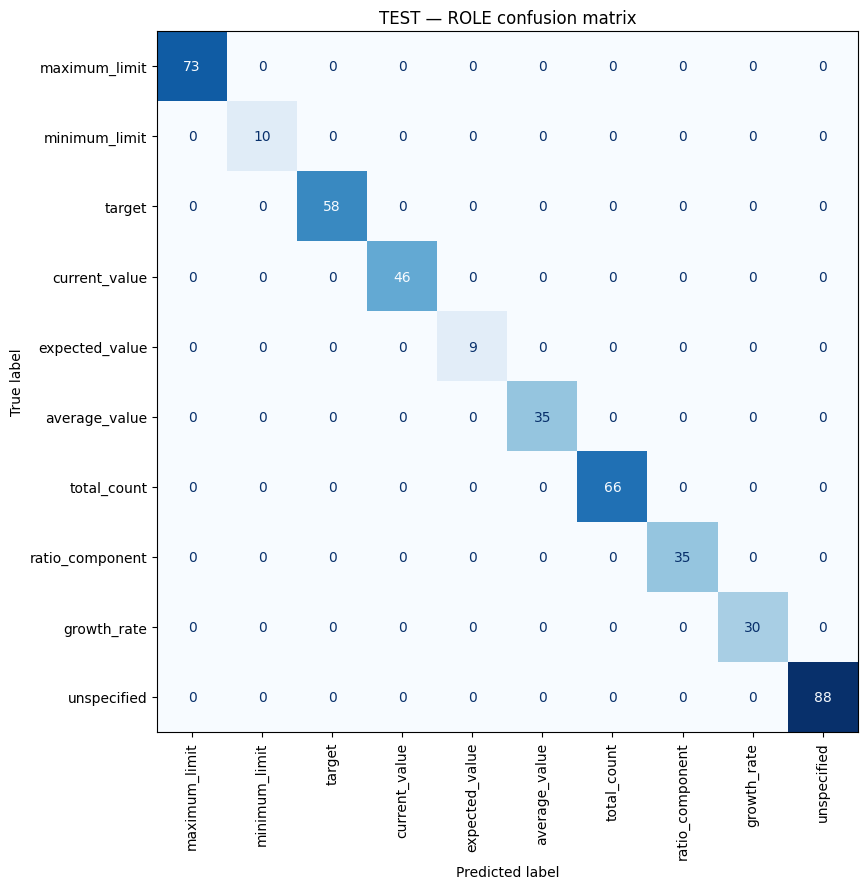

In [16]:
fig,ax=plt.subplots(figsize=(12,10)); ConfusionMatrixDisplay.from_predictions(test_output['true_fields'],test_output['pred_fields'],labels=list(range(NUM_FIELDS)),display_labels=FIELD_LABELS,xticks_rotation=90,cmap='Blues',ax=ax,colorbar=False); ax.set_title('TEST — FIELD confusion matrix'); plt.tight_layout(); plt.show()
fig,ax=plt.subplots(figsize=(11,9)); ConfusionMatrixDisplay.from_predictions(test_output['true_roles'],test_output['pred_roles'],labels=list(range(NUM_ROLES)),display_labels=ROLE_LABELS,xticks_rotation=90,cmap='Blues',ax=ax,colorbar=False); ax.set_title('TEST — ROLE confusion matrix'); plt.tight_layout(); plt.show()

## Cellule 16 — Export complet du meilleur modèle

On sauvegarde encoder, tokenizer, heads, labels, compatibility rules, thresholds, configuration, métriques et historique, puis on crée un ZIP dans `/kaggle/working`.

In [17]:
if EXPORT_DIR.exists(): shutil.rmtree(EXPORT_DIR)
EXPORT_DIR.mkdir(parents=True,exist_ok=True)
model.encoder.save_pretrained(EXPORT_DIR/'encoder',safe_serialization=True)
tokenizer.save_pretrained(EXPORT_DIR/'tokenizer')
torch.save({'field_head':model.field_head.state_dict(),'role_head':model.role_head.state_dict(),'dropout':DROPOUT,'hidden_size':model.encoder.config.hidden_size,'num_fields':NUM_FIELDS,'num_roles':NUM_ROLES},EXPORT_DIR/'classifier_heads.pt')
torch.save(model.state_dict(),EXPORT_DIR/'semantic_linker_full_state.pt')
(EXPORT_DIR/'labels.json').write_text(json.dumps({'field_labels':FIELD_LABELS,'role_labels':ROLE_LABELS},ensure_ascii=False,indent=2),encoding='utf-8')
(EXPORT_DIR/'compatibility.json').write_text(json.dumps({'allowed_fields_by_dimension':{k:sorted(v) for k,v in ALLOWED_FIELDS_BY_DIMENSION.items()},'allowed_roles_by_field':{k:sorted(v) for k,v in ALLOWED_ROLES_BY_FIELD.items()}},ensure_ascii=False,indent=2),encoding='utf-8')
(EXPORT_DIR/'thresholds.json').write_text(json.dumps({'confidence_threshold':CONFIDENCE_THRESHOLD,'margin_threshold':MARGIN_THRESHOLD,'selection_reason':selection_reason,'target_accepted_precision':TARGET_ACCEPTED_PRECISION},indent=2),encoding='utf-8')
training_config={'model_name':MODEL_NAME,'seed':SEED,'max_length':MAX_LENGTH,'batch_size':BATCH_SIZE,'gradient_accumulation_steps':GRAD_ACCUM_STEPS,'effective_batch_size':EFFECTIVE_BATCH_SIZE,'max_epochs':MAX_EPOCHS,'best_epoch':best_epoch,'learning_rate':LEARNING_RATE,'weight_decay':WEIGHT_DECAY,'warmup_ratio':WARMUP_RATIO,'dropout':DROPOUT,'amp':USE_AMP,'gradient_checkpointing':USE_GRADIENT_CHECKPOINTING,'special_tokens':SPECIAL_TOKENS}
(EXPORT_DIR/'training_config.json').write_text(json.dumps(training_config,ensure_ascii=False,indent=2),encoding='utf-8')
(EXPORT_DIR/'validation_metrics.json').write_text(json.dumps({'raw_constrained':{k:float(v) for k,v in val_metrics.items()},'selective':{k:(int(v) if k=='accepted_count' else float(v)) for k,v in selected.to_dict().items()}},indent=2),encoding='utf-8')
(EXPORT_DIR/'test_metrics.json').write_text(json.dumps({'raw_constrained':{k:float(v) for k,v in test_metrics.items()},'selective':{k:(int(v) if k=='accepted_count' else float(v)) for k,v in test_selective.items()}},indent=2),encoding='utf-8')
(EXPORT_DIR/'training_history.json').write_text(json.dumps(history,indent=2),encoding='utf-8')
zip_path=shutil.make_archive('/kaggle/working/semantic_linker_xlmr_base_final','zip',root_dir=EXPORT_DIR)
print('✅ ZIP:',zip_path)
for p in sorted(EXPORT_DIR.rglob('*')):
    if p.is_file(): print(' -',p.relative_to(EXPORT_DIR))

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ ZIP: /kaggle/working/semantic_linker_xlmr_base_final.zip
 - classifier_heads.pt
 - compatibility.json
 - encoder/config.json
 - encoder/model.safetensors
 - labels.json
 - semantic_linker_full_state.pt
 - test_metrics.json
 - thresholds.json
 - tokenizer/tokenizer.json
 - tokenizer/tokenizer_config.json
 - training_config.json
 - training_history.json
 - validation_metrics.json


## Cellule 17 — Démo d'inférence du Semantic Linker ML

Cette fonction reçoit `marked_text + dimension`, applique le modèle, les compatibility rules puis les thresholds. L'intégration avec `QuantityScanner → ExplicitPatternResolver → InputBuilder` sera faite ensuite dans le projet local.

In [18]:
@torch.no_grad()
def predict_one(marked_text,dimension):
    if dimension not in ALLOWED_FIELDS_BY_DIMENSION: raise ValueError(dimension)
    enc=tokenizer(marked_text,return_tensors='pt',truncation=True,max_length=MAX_LENGTH)
    model.eval()
    with autocast_context(): fl,rl=model(enc['input_ids'].to(DEVICE),enc['attention_mask'].to(DEVICE))
    dec=decode_valid_pairs(fl.float().cpu(),rl.float().cpu(),[dimension])
    fi=int(dec['field_ids'][0]); ri=int(dec['role_ids'][0]); conf=float(dec['confidence'][0]); margin=float(dec['margin'][0])
    accepted=(fi!=UNRESOLVED_FIELD_ID and conf>=CONFIDENCE_THRESHOLD and margin>=MARGIN_THRESHOLD)
    return {'raw_best_field':ID_TO_FIELD[fi],'raw_best_role':ID_TO_ROLE[ri],'confidence':conf,'margin':margin,'accepted':accepted,'final_field':ID_TO_FIELD[fi] if accepted else '__UNRESOLVED__','final_role':ID_TO_ROLE[ri] if accepted else 'unspecified'}

examples=[
 ('Around [Q]275[/Q] endpoints will mount the shared filesystem.','unknown'),
 ('Le filesystem devrait absorb environ [Q]80 GB/s[/Q] depuis les data producers.','throughput'),
 ("Un rack sensor a brièvement affiché [Q]800 W[/Q], sans indiquer que c'est une contrainte de conception.",'power'),
]
for text,dim in examples:
    print()
    print('TEXT:', text)
    print('DIM:', dim)
    print(json.dumps(
        predict_one(text,dim),
        ensure_ascii=False,
        indent=2,
    ))


TEXT: Around [Q]275[/Q] endpoints will mount the shared filesystem.
DIM: unknown
{
  "raw_best_field": "client_count",
  "raw_best_role": "total_count",
  "confidence": 0.9991999268531799,
  "margin": 0.9985084489453584,
  "accepted": true,
  "final_field": "client_count",
  "final_role": "total_count"
}

TEXT: Le filesystem devrait absorb environ [Q]80 GB/s[/Q] depuis les data producers.
DIM: throughput
{
  "raw_best_field": "target_write_gbps",
  "raw_best_role": "target",
  "confidence": 0.9965267777442932,
  "margin": 0.9948132507270202,
  "accepted": true,
  "final_field": "target_write_gbps",
  "final_role": "target"
}

TEXT: Un rack sensor a brièvement affiché [Q]800 W[/Q], sans indiquer que c'est une contrainte de conception.
DIM: power
{
  "raw_best_field": "__UNRESOLVED__",
  "raw_best_role": "unspecified",
  "confidence": 0.9996905326843262,
  "margin": 0.9993810572486836,
  "accepted": false,
  "final_field": "__UNRESOLVED__",
  "final_role": "unspecified"
}


# Fin — fichier à récupérer

Dans les Outputs Kaggle, récupère :

```text
semantic_linker_xlmr_base_final.zip
```

Il contient le checkpoint sélectionné sur VALIDATION, le tokenizer avec `[Q]`/`[/Q]`, les deux heads, les labels, les compatibility rules, les seuils et les métriques.

Ensuite, l'intégration locale sera :

```text
QuantityScanner
→ ExplicitPatternResolver
→ unresolved
→ SemanticLinkerInputBuilder
→ XLM-R checkpoint
→ FIELD + ROLE
→ compatibility + thresholds
→ SemanticLink
→ DeterministicVerifier
```

In [21]:
import os
import shutil
from IPython.display import FileLink, display

WORKING_DIR = "/kaggle/working"
EXPECTED_FOLDER = "semantic_linker_xlmr_base_final"

print("=" * 70)
print("📂 Contenu de /kaggle/working")
print("=" * 70)

for item in sorted(os.listdir(WORKING_DIR)):
    path = os.path.join(WORKING_DIR, item)

    if os.path.isdir(path):
        print(f"📁 {item}")
    else:
        size_mb = os.path.getsize(path) / (1024 ** 2)
        print(f"📄 {item} ({size_mb:.2f} MB)")


# ---------------------------------------------------------
# Recherche du dossier exporté
# ---------------------------------------------------------

folder_path = os.path.join(
    WORKING_DIR,
    EXPECTED_FOLDER
)

if not os.path.isdir(folder_path):

    print("\n⚠️ Dossier attendu non trouvé :")
    print(folder_path)

    print("\nDossiers disponibles :")

    folders = []

    for item in os.listdir(WORKING_DIR):
        path = os.path.join(WORKING_DIR, item)

        if os.path.isdir(path):
            folders.append(item)
            print("   📁", item)

    raise FileNotFoundError(
        "\nLe dossier semantic_linker_xlmr_base_final "
        "n'existe pas encore.\n"
        "Exécute d'abord la cellule d'export du modèle."
    )


# ---------------------------------------------------------
# Vérification rapide du contenu du modèle
# ---------------------------------------------------------

print("\n" + "=" * 70)
print("🔎 Contenu du modèle")
print("=" * 70)

for item in sorted(os.listdir(folder_path)):
    path = os.path.join(folder_path, item)

    if os.path.isdir(path):
        print(f"📁 {item}/")
    else:
        print(f"📄 {item}")


# ---------------------------------------------------------
# Création du ZIP
# ---------------------------------------------------------

zip_base = os.path.join(
    WORKING_DIR,
    EXPECTED_FOLDER
)

zip_path = zip_base + ".zip"

# Supprimer un ancien ZIP pour éviter toute confusion
if os.path.exists(zip_path):
    os.remove(zip_path)

zip_path = shutil.make_archive(
    zip_base,
    "zip",
    root_dir=WORKING_DIR,
    base_dir=EXPECTED_FOLDER,
)


# ---------------------------------------------------------
# Résultat
# ---------------------------------------------------------

zip_size_mb = os.path.getsize(zip_path) / (1024 ** 2)

print("\n" + "=" * 70)
print("✅ MODÈLE ZIPPÉ AVEC SUCCÈS")
print("=" * 70)

print("Dossier :", folder_path)
print("ZIP     :", zip_path)
print(f"Taille  : {zip_size_mb:.2f} MB")

print("\n⬇️ Clique sur le lien ci-dessous pour télécharger :\n")

display(FileLink(zip_path))

📂 Contenu de /kaggle/working
📁 .virtual_documents
📁 semantic_linker_xlmr_base
📄 semantic_linker_xlmr_base_final.zip (1500.43 MB)

⚠️ Dossier attendu non trouvé :
/kaggle/working/semantic_linker_xlmr_base_final

Dossiers disponibles :
   📁 .virtual_documents
   📁 semantic_linker_xlmr_base


FileNotFoundError: 
Le dossier semantic_linker_xlmr_base_final n'existe pas encore.
Exécute d'abord la cellule d'export du modèle.